<a href="https://colab.research.google.com/github/AgnelFernando/HealthAIAgent/blob/master/notebooks/SyntheticUserGeneration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install pandas numpy psycopg2-binary sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 22.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
from sqlalchemy import create_engine, text
from datetime import datetime

from google.colab import userdata

DB_URL = userdata.get("DATABASE_URL")
engine = create_engine(DB_URL)

df_users = pd.DataFrame([
    {
        "name": "Eva Wright",
        "dob": "1984-03-21",
        "gender": "female",
        "weight_lb": 132.8,
        "height_cm": 157,
        "goal": "improve_sleep"
    },
    {
        "name": "Gary Lord",
        "dob": "1998-12-29",
        "gender": "male",
        "weight_lb": 211.0,
        "height_cm": 178,
        "goal": "muscle_gain"
    },
    {
        "name": "Ann Cardwell",
        "dob": "1974-03-17",
        "gender": "female",
        "weight_lb": 123.2,
        "height_cm": 167,
        "goal": "stress_reduction"
    }
])
df_users.to_sql("users", engine, if_exists="append", index=False)

print("Inserted users successfully!")

Inserted users successfully!


In [3]:
with engine.connect() as conn:
    result = conn.execute(text("SELECT id, name FROM users;"))
    users_db = result.fetchall()

users_db

[(UUID('f4bff16d-d355-4d69-9769-7ea45bb31755'), 'Eva Wright'),
 (UUID('557975cf-2b37-4f1f-8d7e-0b80921d2db7'), 'Gary Lord'),
 (UUID('6d8768a1-88c3-4d1f-bc55-29da4aa90941'), 'Ann Cardwell')]

In [8]:
import numpy as np
import pandas as pd
from datetime import date, timedelta

np.random.seed(42)

def gen_user_days(user_id, start_date, days, profile):
    rows = []
    baseline_sleep = profile["sleep_mean"]
    baseline_rhr   = profile["rhr_mean"]
    baseline_hrv   = profile["hrv_mean"]
    baseline_steps = profile["steps_mean"]

    # event windows
    bad_sleep_start = profile["bad_sleep_start"]
    overtrain_start = profile["overtrain_start"]

    for i in range(days):
        d = start_date + timedelta(days=i)

        # base signals
        sleep = np.random.normal(baseline_sleep, 35)
        steps = np.random.normal(baseline_steps, baseline_steps * 0.15)
        active = int(max(0, (steps / 150)))

        # events
        if bad_sleep_start <= i < bad_sleep_start + 7:
            sleep -= np.random.uniform(60, 120)

        if overtrain_start <= i < overtrain_start + 7:
            active += np.random.uniform(30, 60)
            steps += np.random.uniform(2500, 6000)

        deep_pct = np.clip(np.random.normal(0.20, 0.04), 0.10, 0.30)
        rem_pct  = np.clip(np.random.normal(0.23, 0.04), 0.12, 0.33)

        sleep_deficit = max(0, (baseline_sleep - sleep) / 60)  # hours
        rhr = np.random.normal(baseline_rhr, 2) + sleep_deficit * 1.5

        training_load = max(0, (active - 45) / 30)
        hrv = np.random.normal(baseline_hrv, 5) - training_load * 6 - sleep_deficit * 2

        sleep = int(np.clip(sleep, 240, 540))
        steps = int(np.clip(steps, 500, 20000))
        active = int(np.clip(active, 0, 180))
        rhr = float(np.clip(rhr, 45, 95))
        hrv = float(np.clip(hrv, 15, 120))

        rows.append({
            "user_id": user_id,
            "date": d.isoformat(),
            "sleep_minutes": sleep,
            "deep_sleep_pct": round(deep_pct * 100, 1),
            "rem_sleep_pct": round(rem_pct * 100, 1),
            "resting_hr": round(rhr, 1),
            "hrv": round(hrv, 1),
            "steps": steps,
            "active_minutes": active
        })

    return pd.DataFrame(rows)

start = date.today() - timedelta(days=90)
days = 90

profiles = [
    {"sleep_mean": 430, "rhr_mean": 58, "hrv_mean": 72, "steps_mean": 11000, "bad_sleep_start": 20, "overtrain_start": 55},
    {"sleep_mean": 410, "rhr_mean": 65, "hrv_mean": 55, "steps_mean": 8000, "bad_sleep_start": 35, "overtrain_start": 60},
    {"sleep_mean": 380, "rhr_mean": 74, "hrv_mean": 38, "steps_mean": 5000, "bad_sleep_start": 15, "overtrain_start": 45},
]

dfs = []
for idx, profile in enumerate(profiles, start=1):
    dfs.append(gen_user_days(user_id=users_db[idx-1][0], start_date=start, days=days, profile=profile))

df = pd.concat(dfs, ignore_index=True)
df.head(), df.shape

(                                user_id        date  sleep_minutes  \
 0  f4bff16d-d355-4d69-9769-7ea45bb31755  2025-12-01            447   
 1  f4bff16d-d355-4d69-9769-7ea45bb31755  2025-12-02            485   
 2  f4bff16d-d355-4d69-9769-7ea45bb31755  2025-12-03            438   
 3  f4bff16d-d355-4d69-9769-7ea45bb31755  2025-12-04            398   
 4  f4bff16d-d355-4d69-9769-7ea45bb31755  2025-12-05            410   
 
    deep_sleep_pct  rem_sleep_pct  resting_hr   hrv  steps  active_minutes  
 0            22.6           29.1        57.5  65.6  10771              71  
 1            18.1           25.2        57.1  62.5  12266              81  
 2            13.1           20.8        56.0  72.2   7843              52  
 3            25.9           22.1        58.9  61.4   8669              57  
 4            15.4           24.5        57.3  64.1  11183              74  ,
 (270, 9))

In [9]:
df.to_sql("daily_metrics", engine, if_exists="append", index=False)
print("Inserted:", len(df))

Inserted: 270


In [ ]:
df

In [13]:
u

,user_id,date,sleep_minutes,deep_sleep_pct,rem_sleep_pct,resting_hr,hrv,steps,active_minutes


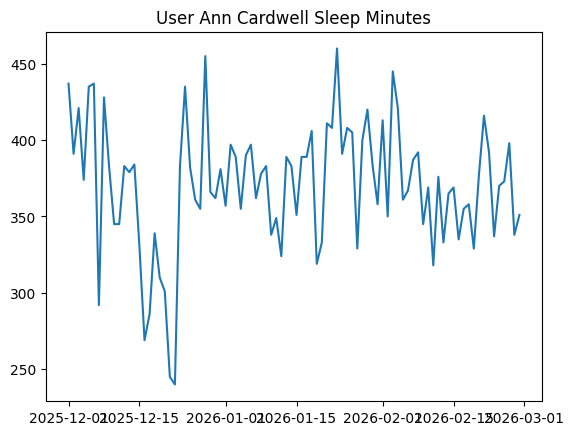

In [17]:
import matplotlib.pyplot as plt

id = 2

u = df[df["user_id"]==users_db[id][0]].copy()
u["date"] = pd.to_datetime(u["date"])
u = u.sort_values("date")

plt.figure()
plt.plot(u["date"], u["sleep_minutes"])
plt.title(f"User {users_db[id][1]} Sleep Minutes")
plt.show()

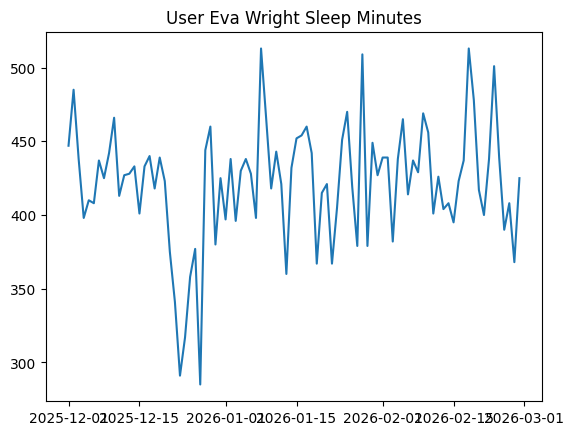

In [18]:
import matplotlib.pyplot as plt

id = 0

u = df[df["user_id"]==users_db[id][0]].copy()
u["date"] = pd.to_datetime(u["date"])
u = u.sort_values("date")

plt.figure()
plt.plot(u["date"], u["sleep_minutes"])
plt.title(f"User {users_db[id][1]} Sleep Minutes")
plt.show()